# Working with Pandemic Data

This notebook evaluates seven imputation methods for filling the COVID-19 gap in the Brazil tourism arrivals time series.

**Approach:** select multiple non-overlapping pre-COVID windows, mask each one to simulate a gap, fit/apply each method using only the data *before* (and where applicable *after*) the masked window, and measure reconstruction error against the ground truth.

**Methods compared:**
1. Linear interpolation (time-based)
2. STL + PCHIP — STL decomposition fitted on pre-gap data; seasonal component projected forward into the gap; PCHIP interpolation applied to the trend only, then seasonal added back
3. Spline interpolation (order=3)
4. Auto ARIMA — forward SARIMAX fitted on pre-gap data only
5. Auto ARIMA (backward) — SARIMAX fitted on *reversed* post-gap data, predictions re-reversed to chronological order
6. ARIMA blend — linear-decay weighted average of forward and backward ARIMA forecasts
7. **AutoStat + ARIMA (fwd)** — AutoML approach: `AutoStationaryTransformer` (Joseph & Tackes, *Modern Time Series Forecasting with Python* 2E) makes the pre-gap series stationary (detrend → deseasonalize → Box-Cox with Guerrero λ, each step triggered by a statistical test), an auto-ARIMA is fitted on the stationary series, and the forecast across the gap is inverse-transformed back to arrival counts

**Metrics:**
- MAE, RMSE, MAPE — pointwise reconstruction error vs. ground truth
- **Variance gap** — `|var(ground truth) − var(imputed)|` over the gap, to detect methods that produce overly smooth (or overly spiky) reconstructions
- **Downstream-ARIMA RMSE / MAPE (leakage-free)** — for each method, fit an auto ARIMA on `[gap_start − 24m, 2019-06-30]` (24 months pre-gap real + 24-month imputed gap + all post-gap real up to 2019-06-30) and evaluate 6-month-ahead forecast accuracy on `2019-07-01 → 2019-12-31`. The two methods that *could* see the test window — backward ARIMA (fits on post-gap data) and spline (global cubic fit) — are re-imputed on a copy of the series truncated at 2019-06-30, so no method's gap values reflect the test region. An **oracle baseline** (auto-ARIMA fitted on the same span but with the *real* gap values instead of an imputation) is logged per window as a reference.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings('ignore')

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-01-01')
COVID_END = pd.Timestamp('2021-12-31')

sns.set_palette('colorblind')

### Helper Functions — Modern Time Series Forecasting with Python (2E)

The AutoML stationarity pipeline comes from the companion repository of:

> Joseph, M. & Tackes, J. *Modern Time Series Forecasting with Python*, 2nd ed.
> (Packt, 2024) — [PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E](https://github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E), MIT License

`AutoStationaryTransformer` (`src/transforms/target_transformations.py`) chains, during
`fit`, the tests explored in notebook 3:

1. `check_trend` (Mann-Kendall). If a trend is found → `DetrendingTransformer`.
2. `check_seasonality` at m = 12. If seasonal → `DeseasonalizingTransformer`.
3. `check_heteroscedastisticity` (White). If heteroscedastic → `AddMTransformer` when
   needed, then `BoxCoxTransformer` with Guerrero λ.

The fitted pipeline has an exact `inverse_transform`, which lets us forecast in the
stationary space and map the forecasts back to arrival counts. The repository is expected
as a sibling folder of this project (override with the `MTSF_REPO_PATH` environment
variable).

In [2]:
import sys

# Helpers credited to: Joseph, M. & Tackes, J. "Modern Time Series Forecasting with
# Python", 2nd ed. (Packt, 2024) — MIT License
# github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E
MTSF_REPO_PATH = os.getenv(
    'MTSF_REPO_PATH',
    os.path.join(
        os.path.dirname(ROOT_PATH), 'Modern-Time-Series-Forecasting-with-Python-2E'
    ),
)
if MTSF_REPO_PATH not in sys.path:
    sys.path.insert(0, MTSF_REPO_PATH)

from src.transforms.target_transformations import (  # noqa: E402
    AutoStationaryTransformer,
    BoxCoxTransformer,
)

SEASONAL_PERIOD = 12
FREQ = 'ME'

## Data Import

Train + validation (`train.parquet` and `val.parquet`, notebook 2). The validation year is
the forecast target of the *Simple Testing with Pandemic Data* section. The test set is never
read here.

In [3]:
df = pd.concat(
    [
        pd.read_parquet(os.path.join(DATA_FOLDER_PATH, file_name))
        for file_name in ['train.parquet', 'val.parquet']
    ],
    ignore_index=True,
)
df = df.set_index('date')

monthly_df = df[['arrival_count']].resample('ME').sum()

print(
    f'Series range : {monthly_df.index.min().date()} → {monthly_df.index.max().date()}'
)
print(f'Total months : {len(monthly_df)}')
monthly_df.head()

Series range : 1989-01-31 → 2025-08-31
Total months : 440


,arrival_count
date,
1989-01-31,291566.0
1989-02-28,197348.0
1989-03-31,149001.0
1989-04-30,84867.0
1989-05-31,69293.0


## Imputation Benchmark

### Test Windows

Thirteen pre-COVID windows of varying lengths (6 → 36 months) spanning 1995 → 2015. All windows are constrained so that the downstream-ARIMA test window stays inside the pre-COVID region (i.e. `gap_end + 48m ≤ 2019-12-31`).

The benchmark splits naturally in two groups:
- **W0 → W6** — older, non-overlapping windows scattered across historical regimes.
- **W7 → W12** — recent-year stress test: six windows of decreasing length (36m → 6m) all *ending at 2015-12-31* (the latest legal `gap_end`). These overlap heavily by construction; the goal is to measure how each method scales with gap length while holding the surrounding context fixed.

The **downstream-ARIMA metric** uses a fixed per-window geometry, anchored on each gap (all values inclusive, month-end stamps):

| segment              | months | offset from gap |
|----------------------|--------|------------------|
| DS train (pre-gap)   | 24     | gap_start − 24m … gap_start − 1m  |
| DS gap (imputed)     | 6–36   | gap_start … gap_end (per-window)  |
| DS train (post-gap)  | 36     | gap_end + 1m … gap_end + 36m      |
| DS test (real)       | 12     | gap_end + 37m … gap_end + 48m     |

Resulting per-window spans:

| Window | Gap                                     | DS pre-train (24m)         | DS post-train (36m)        | DS test (12m)              |
|--------|-----------------------------------------|----------------------------|----------------------------|----------------------------|
| W0     | 1995-01-31 → 1995-06-30 (**6m**)        | 1993-01-31 → 1994-12-31    | 1995-07-31 → 1998-06-30    | 1998-07-31 → 1999-06-30    |
| W1     | 1998-01-31 → 1998-12-31 (**12m**)       | 1996-01-31 → 1997-12-31    | 1999-01-31 → 2001-12-31    | 2002-01-31 → 2002-12-31    |
| W2     | 2001-01-31 → 2002-06-30 (**18m**)       | 1999-01-31 → 2000-12-31    | 2002-07-31 → 2005-06-30    | 2005-07-31 → 2006-06-30    |
| W3     | 2004-01-31 → 2006-12-31 (**36m**)       | 2002-01-31 → 2003-12-31    | 2007-01-31 → 2009-12-31    | 2010-01-31 → 2010-12-31    |
| W4     | 2008-01-31 → 2009-12-31 (24m)           | 2006-01-31 → 2007-12-31    | 2010-01-31 → 2012-12-31    | 2013-01-31 → 2013-12-31    |
| W5     | 2010-01-31 → 2011-12-31 (24m)           | 2008-01-31 → 2009-12-31    | 2012-01-31 → 2014-12-31    | 2015-01-31 → 2015-12-31    |
| W6     | 2012-01-31 → 2013-12-31 (24m)           | 2010-01-31 → 2011-12-31    | 2014-01-31 → 2016-12-31    | 2017-01-31 → 2017-12-31    |
| W7     | 2013-01-31 → 2015-12-31 (**36m**)       | 2011-01-31 → 2012-12-31    | 2016-01-31 → 2018-12-31    | 2019-01-31 → 2019-12-31    |
| W8     | 2013-07-31 → 2015-12-31 (**30m**)       | 2011-07-31 → 2013-06-30    | 2016-01-31 → 2018-12-31    | 2019-01-31 → 2019-12-31    |
| W9     | 2014-01-31 → 2015-12-31 (24m)           | 2012-01-31 → 2013-12-31    | 2016-01-31 → 2018-12-31    | 2019-01-31 → 2019-12-31    |
| W10    | 2014-07-31 → 2015-12-31 (**18m**)       | 2012-07-31 → 2014-06-30    | 2016-01-31 → 2018-12-31    | 2019-01-31 → 2019-12-31    |
| W11    | 2015-01-31 → 2015-12-31 (**12m**)       | 2013-01-31 → 2014-12-31    | 2016-01-31 → 2018-12-31    | 2019-01-31 → 2019-12-31    |
| W12    | 2015-07-31 → 2015-12-31 (**6m**)        | 2013-07-31 → 2015-06-30    | 2016-01-31 → 2018-12-31    | 2019-01-31 → 2019-12-31    |

Because W7–W12 share the same `gap_end`, they also share the same DS post-train and DS test windows — the only thing that varies is how much real data is replaced by the imputation. The DS-RMSE/DS-MAPE differences inside that cluster are therefore *purely* a function of gap length.

The reconstruction metrics use the *full* pre-COVID post-gap span (up to 2019-12-31) for backward ARIMA fitting; only the downstream-ARIMA metric uses the truncated per-window geometry above so that each method's gap imputation is leakage-free relative to its own test window. Windows are ordered chronologically by `gap_start`.

In [4]:
WINDOWS = [
    # Older, well-spaced windows across historical regimes.
    ('W0', pd.Timestamp('1995-01-31'), pd.Timestamp('1995-06-30')),  # 6m
    ('W1', pd.Timestamp('1998-01-31'), pd.Timestamp('1998-12-31')),  # 12m
    ('W2', pd.Timestamp('2001-01-31'), pd.Timestamp('2002-06-30')),  # 18m
    ('W3', pd.Timestamp('2004-01-31'), pd.Timestamp('2006-12-31')),  # 36m
    ('W4', pd.Timestamp('2008-01-31'), pd.Timestamp('2009-12-31')),  # 24m
    ('W5', pd.Timestamp('2010-01-31'), pd.Timestamp('2011-12-31')),  # 24m
    ('W6', pd.Timestamp('2012-01-31'), pd.Timestamp('2013-12-31')),  # 24m
    ('W7', pd.Timestamp('2013-01-31'), pd.Timestamp('2015-12-31')),  # 36m
    ('W8', pd.Timestamp('2013-07-31'), pd.Timestamp('2015-12-31')),  # 30m
    ('W9', pd.Timestamp('2014-01-31'), pd.Timestamp('2015-12-31')),  # 24m
    ('W10', pd.Timestamp('2014-07-31'), pd.Timestamp('2015-12-31')),  # 18m
    ('W11', pd.Timestamp('2015-01-31'), pd.Timestamp('2015-12-31')),  # 12m
    ('W12', pd.Timestamp('2015-07-31'), pd.Timestamp('2015-12-31')),  # 6m
]

RANDOM_STATE = 42  # for reproducibility of auto_arima search

for name, start, end in WINDOWS:
    n = monthly_df.loc[start:end].shape[0]
    print(f'{name}: {start.date()} → {end.date()} ({n} months)')

W0: 1995-01-31 → 1995-06-30 (6 months)
W1: 1998-01-31 → 1998-12-31 (12 months)
W2: 2001-01-31 → 2002-06-30 (18 months)
W3: 2004-01-31 → 2006-12-31 (36 months)
W4: 2008-01-31 → 2009-12-31 (24 months)
W5: 2010-01-31 → 2011-12-31 (24 months)
W6: 2012-01-31 → 2013-12-31 (24 months)
W7: 2013-01-31 → 2015-12-31 (36 months)
W8: 2013-07-31 → 2015-12-31 (30 months)
W9: 2014-01-31 → 2015-12-31 (24 months)
W10: 2014-07-31 → 2015-12-31 (18 months)
W11: 2015-01-31 → 2015-12-31 (12 months)
W12: 2015-07-31 → 2015-12-31 (6 months)


### Helper Functions

In [5]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def apply_linear(series_with_nan):
    return series_with_nan.interpolate(method='time').clip(lower=0)


def apply_stl_pchip(series_with_nan, gap_mask, pre_gap_end):
    "STL decomposition on pre-gap data; project seasonal forward; PCHIP the trend."
    pre_gap = series_with_nan[series_with_nan.index <= pre_gap_end].dropna()

    stl = STL(pre_gap, period=12, seasonal=13, robust=True)
    stl_res = stl.fit()

    # tile the last full year's seasonal pattern over the gap
    n_gap = int(gap_mask.sum())
    seasonal_pattern = stl_res.seasonal[-12:].values
    projected_seasonal = np.tile(seasonal_pattern, n_gap // 12 + 1)[:n_gap]

    # interpolate trend across the full series (gap included as NaN)
    trend_interp = series_with_nan.interpolate(method='pchip')

    result = series_with_nan.copy()
    result[gap_mask] = (trend_interp[gap_mask].values + projected_seasonal).clip(min=0)
    return result


def apply_spline(series_with_nan):
    return series_with_nan.interpolate(method='spline', order=3).clip(lower=0)


def apply_auto_arima(series_with_nan, gap_mask, pre_gap_end):
    "Fit SARIMAX on data strictly before the gap, forecast across the gap."
    pre_gap = series_with_nan[series_with_nan.index <= pre_gap_end].dropna()
    n_gap = int(gap_mask.sum())
    model = auto_arima(
        pre_gap,
        seasonal=True,
        m=12,
        stepwise=False,
        n_jobs=-1,
        max_p=2,
        max_q=2,
        max_P=2,
        max_Q=2,
        d=1,
        D=0,
        information_criterion='aicc',
        out_of_sample_size=12,
        error_action='ignore',
        suppress_warnings=True,
        random_state=RANDOM_STATE,
    )
    forecast = np.asarray(model.predict(n_periods=n_gap))
    result = series_with_nan.copy()
    result[gap_mask] = np.clip(forecast, 0, None)
    return result, model, forecast


def apply_auto_arima_bwd(series_with_nan, gap_mask, post_gap_start, post_gap_end):
    """Fit SARIMAX on *reversed* post-gap data, predict backward across the gap.

    The post-gap slice is reversed to a plain numpy array (avoids index-mismatch
    during fitting); the model learns trend/seasonality moving backward in time;
    the forecast is then reversed so it aligns chronologically with the gap.
    """
    post_gap = series_with_nan[
        (series_with_nan.index >= post_gap_start)
        & (series_with_nan.index <= post_gap_end)
    ].dropna()
    n_gap = int(gap_mask.sum())

    reversed_arr = post_gap.values[::-1]
    model = auto_arima(
        reversed_arr,
        seasonal=True,
        m=12,
        stepwise=False,
        n_jobs=-1,
        max_p=2,
        max_q=2,
        max_P=2,
        max_Q=2,
        d=1,
        D=0,
        information_criterion='aicc',
        out_of_sample_size=12,
        error_action='ignore',
        suppress_warnings=True,
        random_state=RANDOM_STATE,
    )
    forecast_bwd_raw = np.asarray(model.predict(n_periods=n_gap))
    forecast_bwd = forecast_bwd_raw[::-1]  # restore chronological order

    result = series_with_nan.copy()
    result[gap_mask] = np.clip(forecast_bwd, 0, None)
    return result, model, forecast_bwd


def apply_arima_blend(series_with_nan, gap_mask, forecast_fwd, forecast_bwd):
    """Linear-decay weighted average: 100% forward at gap start → 100% backward at gap end."""
    n_gap = int(gap_mask.sum())
    w = np.linspace(1.0, 0.0, n_gap)
    imputed = w * forecast_fwd + (1.0 - w) * forecast_bwd

    result = series_with_nan.copy()
    result[gap_mask] = np.clip(imputed, 0, None)
    return result


# ---- Downstream-ARIMA metric (per-window leakage-free geometry) ----
#
# All three deltas are anchored on each window's gap:
#   train = [gap_start − N_DS_PRE m, gap_start − 1m]  +  imputed gap  +  [gap_end + 1m, gap_end + N_DS_POST m]
#   test  = [gap_end + N_DS_POST + 1m, gap_end + N_DS_POST + N_DS_TEST m]
#
# N_DS_POST is set to 36 (3 seasonal cycles) so the backward ARIMA's OCSB
# seasonal-differencing test has enough samples (24 is on the edge and triggers
# "no samples after first-order seasonal differencing").
N_DS_PRE = 24
N_DS_POST = 36
N_DS_TEST = 12


def ds_train_end_for(gap_end, n_post=N_DS_POST):
    "Last month included in the downstream train for a given gap."
    return gap_end + pd.DateOffset(months=n_post)


def _fit_predict_auto_arima(train_values, n_periods):
    model = auto_arima(
        train_values,
        seasonal=True,
        m=12,
        stepwise=False,
        n_jobs=-1,
        max_p=2,
        max_q=2,
        max_P=2,
        max_Q=2,
        d=1,
        D=0,
        information_criterion='aicc',
        out_of_sample_size=12,
        error_action='ignore',
        suppress_warnings=True,
        random_state=RANDOM_STATE,
    )
    return np.asarray(model.predict(n_periods=n_periods))


def downstream_arima_scores(
    full_series,
    imputed_series,
    gap_start,
    gap_end,
    n_pre=N_DS_PRE,
    n_post=N_DS_POST,
    n_test=N_DS_TEST,
    data_cutoff=None,
):
    """Train auto_arima on [gap_start − n_pre, gap_end + n_post] using real pre/post-gap
    values plus the supplied (leakage-free) imputation for the gap itself. Forecast n_test
    months and score against the real series.

    If `data_cutoff` is given and `test_end > data_cutoff`, the metric is skipped
    (returns NaN) — used to refuse test windows that extend into the COVID anomaly.
    """
    train_start = gap_start - pd.DateOffset(months=n_pre)
    train_end = gap_end + pd.DateOffset(months=n_post)
    test_end = train_end + pd.DateOffset(months=n_test)

    if data_cutoff is not None and test_end > data_cutoff:
        return np.nan, np.nan

    train = imputed_series.loc[train_start:train_end].copy()
    pre_idx = train.index[train.index < gap_start]
    post_idx = train.index[train.index > gap_end]
    train.loc[pre_idx] = full_series.loc[pre_idx]
    train.loc[post_idx] = full_series.loc[post_idx]

    test = full_series.loc[
        (full_series.index > train_end) & (full_series.index <= test_end)
    ]
    if len(test) < n_test or train.isna().any():
        return np.nan, np.nan

    forecast = _fit_predict_auto_arima(train.values, n_test)
    return rmse(test.values, forecast), mape(test.values, forecast)


def oracle_arima_scores(
    full_series,
    gap_start,
    gap_end,
    n_pre=N_DS_PRE,
    n_post=N_DS_POST,
    n_test=N_DS_TEST,
    data_cutoff=None,
):
    "Same train/test geometry as downstream_arima_scores but with the *real* gap values."
    train_start = gap_start - pd.DateOffset(months=n_pre)
    train_end = gap_end + pd.DateOffset(months=n_post)
    test_end = train_end + pd.DateOffset(months=n_test)

    if data_cutoff is not None and test_end > data_cutoff:
        return np.nan, np.nan

    train = full_series.loc[train_start:train_end]
    test = full_series.loc[
        (full_series.index > train_end) & (full_series.index <= test_end)
    ]
    if len(test) < n_test:
        return np.nan, np.nan

    forecast = _fit_predict_auto_arima(train.values, n_test)
    return rmse(test.values, forecast), mape(test.values, forecast)


METHOD_STYLES = {
    'Linear': ('steelblue', '-'),
    'STL + PCHIP': ('darkorange', '-'),
    'Spline': ('seagreen', '-'),
    'Auto ARIMA (fwd)': ('mediumpurple', '-'),
    'Auto ARIMA (bwd)': ('crimson', '-'),
    'ARIMA blend': ('teal', '-'),
}

#### AutoML Helper Functions — AutoStationaryTransformer + auto-ARIMA

The seventh method applies the notebook 3 findings to imputation:

- **Fit the transformer on the pre-gap data only.** The EDA showed that λ and the
  trend/seasonality tests must be estimated on a stable regime. Fitting only on the
  pre-gap data also keeps the method leakage-free for the downstream metric, like the
  forward ARIMA.
- **Let auto-ARIMA choose `d` on the stationary series** (`d=None`, `max_d=1`, `D=0`).
  The EDA found the trend to be **stochastic** (ADF `c` vs `ct`). The transformer only
  removes a *deterministic* linear trend, so a unit root may remain and must still be
  differenced away. The forward/backward ARIMA methods keep their fixed `d=1`.
- **Map the forecast back with `inverse_transform`.** The detrender extends the linear
  trend and the deseasonalizer repeats the period averages over the forecast dates, then
  the Box-Cox and offset steps are undone.

In [6]:
# Helper `AutoStationaryTransformer` from Joseph & Tackes, "Modern Time Series
# Forecasting with Python" 2E — src/transforms/target_transformations.py


def fit_auto_stationary(train_series):
    """Fit a fresh AutoStationaryTransformer (Mann-Kendall trend, Guerrero Box-Cox)."""
    # fresh dicts every fit: the transformer mutates its parameter dicts in place
    ast = AutoStationaryTransformer(
        confidence=0.05,
        seasonal_period=SEASONAL_PERIOD,
        trend_check_params={'mann_kendall': True},
        detrender_params={'degree': 1},
        deseasonalizer_params={},
        box_cox_params={'optimization': 'guerrero'},
    )
    return ast.fit(train_series, freq=FREQ)


def describe_pipeline(ast):
    steps = [type(tr).__name__.replace('Transformer', '') for tr in ast._pipeline]
    return ' → '.join(steps) if steps else '(none)'


def fit_predict_auto_stationary_arima(train_series, n_periods):
    """AutoStationaryTransformer → auto-ARIMA on the stationary series → inverse."""
    ast = fit_auto_stationary(train_series)
    stationary = ast.transform(train_series)
    model = auto_arima(
        stationary.to_numpy(),
        seasonal=True,
        m=12,
        stepwise=False,
        n_jobs=-1,
        max_p=2,
        max_q=2,
        max_P=2,
        max_Q=2,
        d=None,
        max_d=1,
        D=0,
        information_criterion='aicc',
        out_of_sample_size=12,
        error_action='ignore',
        suppress_warnings=True,
        random_state=RANDOM_STATE,
    )
    forecast_index = pd.date_range(
        train_series.index[-1] + pd.offsets.MonthEnd(1), periods=n_periods, freq=FREQ
    )
    forecast = ast.inverse_transform(
        pd.Series(np.asarray(model.predict(n_periods=n_periods)), index=forecast_index)
    )
    return np.clip(forecast.to_numpy(), 0, None), ast, model


def apply_auto_stationary_arima(series_with_nan, gap_mask, pre_gap_end):
    """Fit the AutoML pipeline on data strictly before the gap, forecast across it."""
    pre_gap = series_with_nan[series_with_nan.index <= pre_gap_end].dropna()
    n_gap = int(gap_mask.sum())
    forecast, ast, model = fit_predict_auto_stationary_arima(pre_gap, n_gap)
    result = series_with_nan.copy()
    result[gap_mask] = forecast
    return result, ast, model


METHOD_STYLES['AutoStat + ARIMA (fwd)'] = ('saddlebrown', '-')

### Run Benchmark Across All Windows

In [7]:
# ---- Console formatting helpers -------------------------------------------------
# A single column spec drives both the metrics-table header and its rows, so the
# two can never drift out of alignment. Each column is (header, header_align,
# cell_formatter); the cell_formatter renders one value to a fixed-width string.
def _fmt_int(width):
    return lambda v: f'{v:>{width},.0f}'


def _fmt_int_na(width):
    "Integer, right-aligned; non-finite values render as 'n/a'."
    return lambda v: f'{v:>{width},.0f}' if np.isfinite(v) else f'{"n/a":>{width}}'


def _fmt_ratio(width):
    return lambda v: f'{v:>{width}.3f}'


def _fmt_pct(width):
    "Percent with trailing %, right-aligned; non-finite values render as 'n/a'."
    return lambda v: f'{v:>{width - 1}.2f}%' if np.isfinite(v) else f'{"n/a":>{width}}'


METRIC_COLUMNS = [
    ('Method', '<17', lambda v: f'{v:<17}'),
    ('MAE', '>10', _fmt_int(10)),
    ('RMSE', '>10', _fmt_int(10)),
    ('MAPE', '>7', _fmt_pct(7)),
    ('orig_var', '>14', _fmt_int(14)),
    ('pred_var', '>14', _fmt_int(14)),
    ('var_ratio', '>10', _fmt_ratio(10)),
    ('DS-RMSE', '>10', _fmt_int_na(10)),
    ('DS-MAPE', '>8', _fmt_pct(8)),
]


def print_banner(title):
    "Print a window section header bracketed by rules."
    rule = '=' * 55
    print(f'\n{rule}\n  {title}\n{rule}')


def metric_header():
    cells = (f'{label:{align}}' for label, align, _ in METRIC_COLUMNS)
    return '  ' + '  '.join(cells)


def metric_row(values):
    "Render one row; `values` aligns positionally with METRIC_COLUMNS."
    cells = (fmt(v) for (_, _, fmt), v in zip(METRIC_COLUMNS, values))
    return '  ' + '  '.join(cells)


# ---- Benchmark ------------------------------------------------------------------
# ---- Methodology legend (printed once before the per-window run) ----------------
# Explains what each window block below reports, so the log is self-documenting.
print(f'{"=" * 75}')
print('  BENCHMARK METHODOLOGY')
print(f'{"=" * 75}')
print(
    """
  For each pre-COVID window we mask the gap, impute it with seven methods, and
  score the result two ways:

  RECONSTRUCTION metrics  - how close the imputation is to the real gap values.
    MAE / RMSE / MAPE   pointwise error vs. ground truth over the gap.
    orig_var / pred_var variance of the true gap vs. the imputed gap.
    var_ratio           = pred_var / orig_var.  1.0 = ideal; <1 over-smooth
                          (flattened), >1 over-spiky.

  DOWNSTREAM (DS) metrics - does the imputation help a model forecast the FUTURE?
    Fit an auto-ARIMA on  [24m real pre-gap] + [imputed gap] + [36m real post-gap],
    then forecast 12 months and score against the real series.
    DS-RMSE / DS-MAPE   error of that 12-month forecast.
    Built leakage-free: methods that could otherwise peek at the test window
    (backward ARIMA, spline) are re-imputed on a series truncated at the DS
    train end, so no gap value reflects the test region.
    'n/a' = the window's DS test would fall inside COVID, so the metric is skipped.

  ORACLE baseline - same DS train/test geometry but using the REAL gap values
    instead of an imputation. It is the best DS score any imputation could reach;
    treat it as the target each method is chasing, not a competitor.
"""
)

records = []
window_results = {}  # stores imputed series per window for plotting

# Cap post-gap training data at the pre-COVID boundary so the backward model
# never sees the pandemic anomaly (used only by the reconstruction metric).
POST_GAP_CUTOFF = COVID_START - pd.Timedelta(days=1)

for win_name, gap_start, gap_end in WINDOWS:
    print_banner(f'{win_name}: {gap_start.date()} → {gap_end.date()}')

    gap_mask = (monthly_df.index >= gap_start) & (monthly_df.index <= gap_end)
    truth = monthly_df.loc[gap_mask, 'arrival_count'].values
    truth_var = float(np.var(truth))

    masked = monthly_df['arrival_count'].copy()
    masked[gap_mask] = np.nan

    # Training cutoffs
    pre_gap_start = monthly_df.index[0]
    pre_gap_end = monthly_df[monthly_df.index < gap_start].index[-1]
    post_gap_start = monthly_df[monthly_df.index > gap_end].index[0]
    post_gap_end = POST_GAP_CUTOFF
    n_pre = monthly_df.loc[pre_gap_start:pre_gap_end].shape[0]
    n_post = monthly_df.loc[post_gap_start:post_gap_end].shape[0]

    # Downstream-metric geometry (per-window, anchored on gap_end)
    ds_train_end = ds_train_end_for(gap_end)
    ds_test_end = ds_train_end + pd.DateOffset(months=N_DS_TEST)
    ds_in_pre_covid = ds_test_end <= POST_GAP_CUTOFF
    ds_test_start = ds_train_end + pd.DateOffset(days=1)
    ds_status = '' if ds_in_pre_covid else 'test would enter COVID — metric N/A'

    print(
        f'  Pre-gap  training span: {pre_gap_start.date()} → {pre_gap_end.date()} ({n_pre} months)'
    )
    print(
        f'  Post-gap training span: {post_gap_start.date()} → {post_gap_end.date()} ({n_post} months)'
    )
    print(
        f'  Downstream geometry:    train ends {ds_train_end.date()}  |  '
        f'test {ds_test_start.date()} → {ds_test_end.date()}  '
        f'({N_DS_PRE}m pre + {N_DS_POST}m post + {N_DS_TEST}m test){ds_status}'
    )
    print(f'  Ground-truth variance:  {truth_var:,.0f}')

    # ---- Imputations used for the reconstruction metrics (full post-gap context) ----
    s_linear = apply_linear(masked)
    pred_linear = s_linear[gap_mask].values

    s_stl_pchip = apply_stl_pchip(masked, gap_mask, pre_gap_end)
    pred_stl_pchip = s_stl_pchip[gap_mask].values

    s_spline = apply_spline(masked)
    pred_spline = s_spline[gap_mask].values

    s_arima_fwd, arima_fwd_model, forecast_fwd = apply_auto_arima(
        masked, gap_mask, pre_gap_end
    )
    pred_arima_fwd = s_arima_fwd[gap_mask].values
    print(
        f'  ARIMA fwd order:        {arima_fwd_model.order} x {arima_fwd_model.seasonal_order}'
    )

    s_arima_bwd, arima_bwd_model, forecast_bwd = apply_auto_arima_bwd(
        masked, gap_mask, post_gap_start, post_gap_end
    )
    pred_arima_bwd = s_arima_bwd[gap_mask].values
    print(
        f'  ARIMA bwd order:        {arima_bwd_model.order} x {arima_bwd_model.seasonal_order}'
    )

    s_arima_blend = apply_arima_blend(masked, gap_mask, forecast_fwd, forecast_bwd)
    pred_arima_blend = s_arima_blend[gap_mask].values

    # AutoML: AutoStationaryTransformer fitted on pre-gap data only (leakage-free)
    s_ast, ast_fitted, ast_arima_model = apply_auto_stationary_arima(
        masked, gap_mask, pre_gap_end
    )
    pred_ast = s_ast[gap_mask].values
    print(
        f'  AutoStat pipeline:      {describe_pipeline(ast_fitted)}  |  '
        f'ARIMA {ast_arima_model.order} x {ast_arima_model.seasonal_order}'
    )

    # ---- Leakage-free imputations for the downstream metric ----
    # Only build these if the test window fits inside the pre-COVID region; otherwise
    # there's no downstream metric to compute for this window.
    if ds_in_pre_covid:
        masked_lf = masked.copy()
        masked_lf.loc[masked_lf.index > ds_train_end] = np.nan

        s_spline_lf = apply_spline(masked_lf)
        _, _, forecast_bwd_lf = apply_auto_arima_bwd(
            masked_lf, gap_mask, post_gap_start, ds_train_end
        )
        s_arima_bwd_lf = masked.copy()
        s_arima_bwd_lf[gap_mask] = np.clip(forecast_bwd_lf, 0, None)
        s_arima_blend_lf = apply_arima_blend(
            masked, gap_mask, forecast_fwd, forecast_bwd_lf
        )
    else:
        s_spline_lf = s_arima_bwd_lf = s_arima_blend_lf = None

    # Store imputed series for plotting (reconstruction-side imputations)
    window_results[win_name] = {
        'gap_mask': gap_mask,
        'Linear': s_linear,
        'STL + PCHIP': s_stl_pchip,
        'Spline': s_spline,
        'Auto ARIMA (fwd)': s_arima_fwd,
        'Auto ARIMA (bwd)': s_arima_bwd,
        'ARIMA blend': s_arima_blend,
        'AutoStat + ARIMA (fwd)': s_ast,
    }

    # ---- Oracle baseline (real gap values, same downstream geometry) ----
    oracle_rmse, oracle_mape = oracle_arima_scores(
        monthly_df['arrival_count'], gap_start, gap_end, data_cutoff=POST_GAP_CUTOFF
    )
    if np.isfinite(oracle_rmse):
        print(
            f'  Oracle baseline (real gap)        '
            f'DS-RMSE={_fmt_int_na(10)(oracle_rmse)}  DS-MAPE={_fmt_pct(7)(oracle_mape)}'
        )
    else:
        print('  Oracle baseline (real gap)        N/A')

    # ---- Per-method metrics ----
    # (method_name, gap-reconstruction prediction, imputed series for the leakage-free
    # downstream metric — may be None when the window's DS test extends into COVID)
    method_preds = [
        ('Linear', pred_linear, s_linear),
        ('STL + PCHIP', pred_stl_pchip, s_stl_pchip),
        ('Spline', pred_spline, s_spline_lf),
        ('Auto ARIMA (fwd)', pred_arima_fwd, s_arima_fwd),
        ('Auto ARIMA (bwd)', pred_arima_bwd, s_arima_bwd_lf),
        ('ARIMA blend', pred_arima_blend, s_arima_blend_lf),
        ('AutoStat + ARIMA (fwd)', pred_ast, s_ast),
    ]

    print('\n' + metric_header())
    for method_name, pred, s_imputed_lf in method_preds:
        mae_v = mae(truth, pred)
        rmse_v = rmse(truth, pred)
        mape_v = mape(truth, pred)
        pred_var = float(np.var(pred))
        var_ratio = pred_var / truth_var if truth_var > 0 else np.nan

        if s_imputed_lf is not None:
            ds_rmse, ds_mape = downstream_arima_scores(
                monthly_df['arrival_count'],
                s_imputed_lf,
                gap_start,
                gap_end,
                data_cutoff=POST_GAP_CUTOFF,
            )
        else:
            ds_rmse, ds_mape = np.nan, np.nan

        records.append({
            'Window': win_name,
            'Method': method_name,
            'MAE': mae_v,
            'RMSE': rmse_v,
            'MAPE': mape_v,
            'OrigVar': truth_var,
            'PredVar': pred_var,
            'VarRatio': var_ratio,
            'DownstreamRMSE': ds_rmse,
            'DownstreamMAPE': ds_mape,
            'OracleRMSE': oracle_rmse,
            'OracleMAPE': oracle_mape,
        })
        print(
            metric_row([
                method_name,
                mae_v,
                rmse_v,
                mape_v,
                truth_var,
                pred_var,
                var_ratio,
                ds_rmse,
                ds_mape,
            ])
        )

results_df = pd.DataFrame(records)

  BENCHMARK METHODOLOGY

  For each pre-COVID window we mask the gap, impute it with seven methods, and
  score the result two ways:

  RECONSTRUCTION metrics  - how close the imputation is to the real gap values.
    MAE / RMSE / MAPE   pointwise error vs. ground truth over the gap.
    orig_var / pred_var variance of the true gap vs. the imputed gap.
    var_ratio           = pred_var / orig_var.  1.0 = ideal; <1 over-smooth
                          (flattened), >1 over-spiky.

  DOWNSTREAM (DS) metrics - does the imputation help a model forecast the FUTURE?
    Fit an auto-ARIMA on   real pre-gap] + [imputed gap] +  real post-gap],
    then forecast 12 months and score against the real series.
    DS-RMSE / DS-MAPE   error of that 12-month forecast.
    Built leakage-free: methods that could otherwise peek at the test window
    (backward ARIMA, spline) are re-imputed on a series truncated at the DS
    train end, so no gap value reflects the test region.
    'n/a' = the window's D

  ARIMA fwd order:        (0, 1, 0) x (1, 0, 1, 12)
  ARIMA bwd order:        (2, 1, 2) x (1, 0, 0, 12)
  AutoStat pipeline:      Detrending → Deseasonalizing  |  ARIMA (1, 0, 0) x (2, 0, 2, 12)
  Oracle baseline (real gap)        DS-RMSE=    39,783  DS-MAPE=  8.75%

  Method                    MAE        RMSE     MAPE        orig_var        pred_var   var_ratio     DS-RMSE   DS-MAPE
  Linear                 57,966      79,452   27.59%   5,749,626,530      32,975,435       0.006      54,505    11.11%
  STL + PCHIP            35,091      40,473   21.40%   5,749,626,530  13,264,083,930       2.307      39,746     8.77%
  Spline                 44,930      64,370   22.35%   5,749,626,530     335,770,679       0.058      77,306    10.21%
  Auto ARIMA (fwd)       10,675      12,593    5.67%   5,749,626,530   4,429,791,512       0.770      39,756     8.76%
  Auto ARIMA (bwd)       24,246      27,818   13.62%   5,749,626,530   3,998,315,379       0.695      39,774     8.87%
  ARIMA blend     

## Per-Window Visualisations

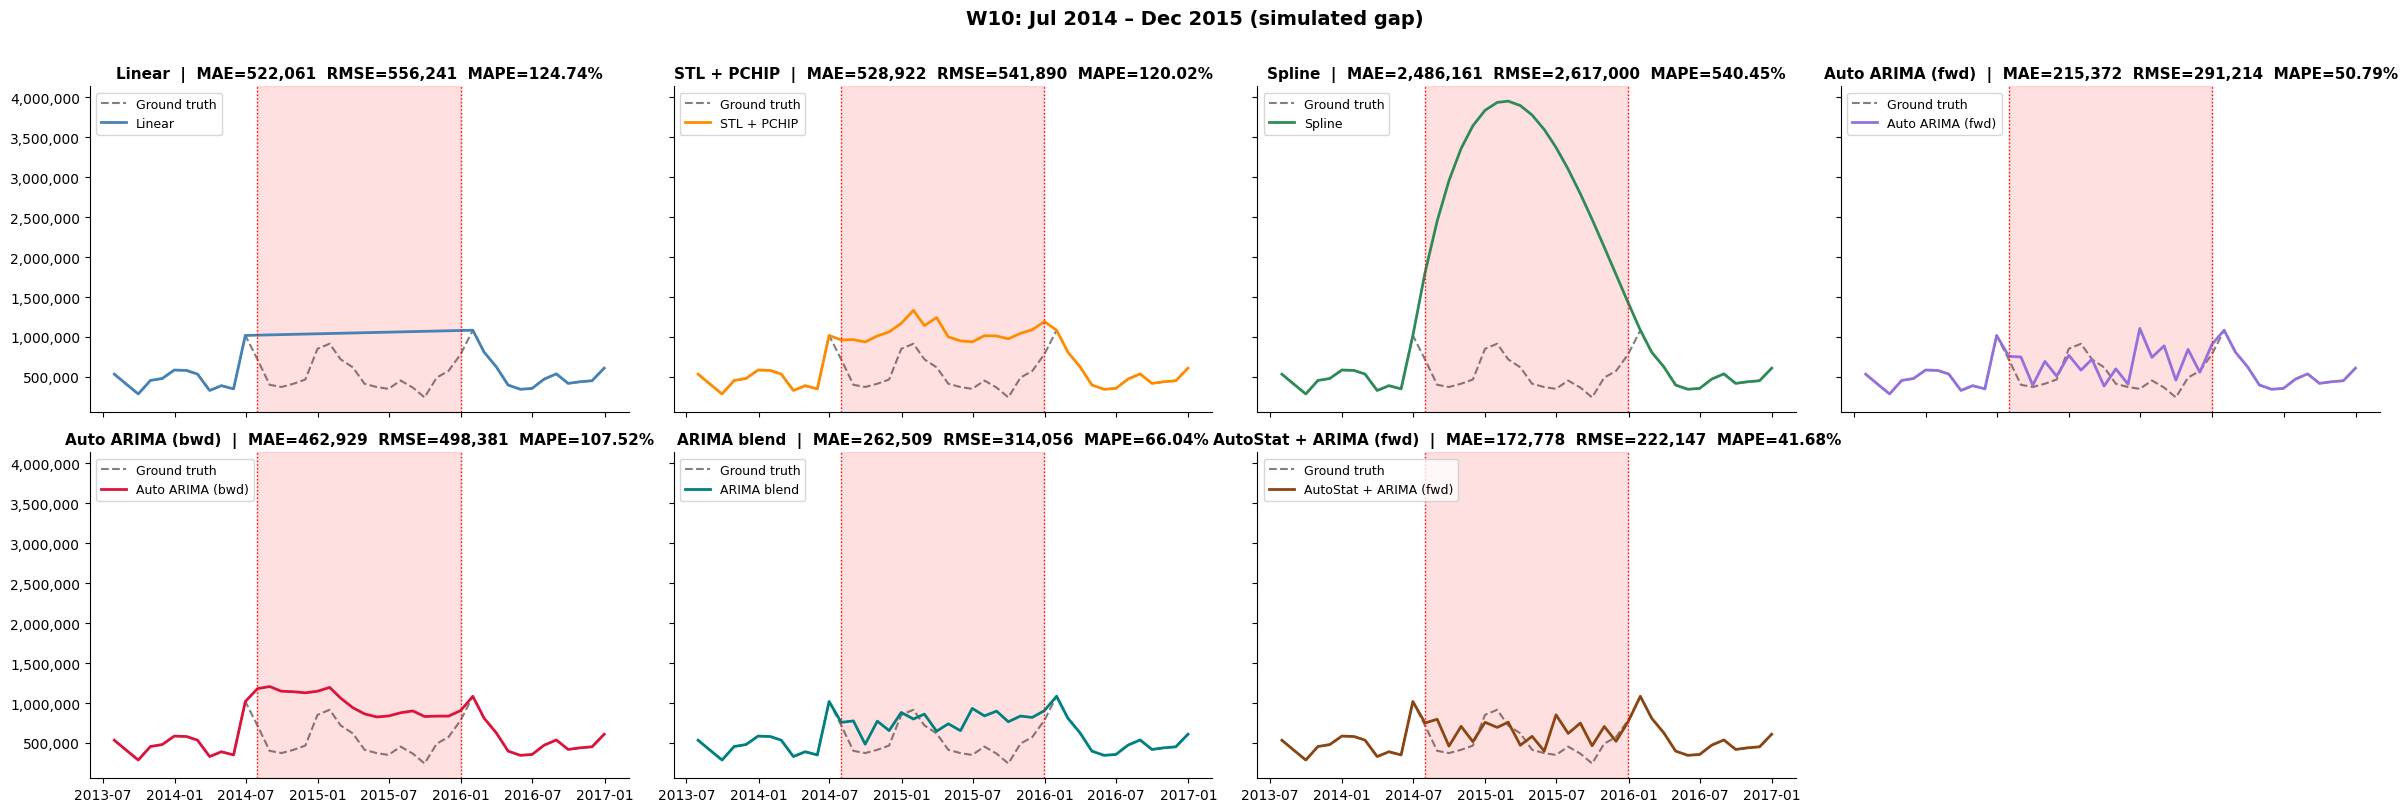

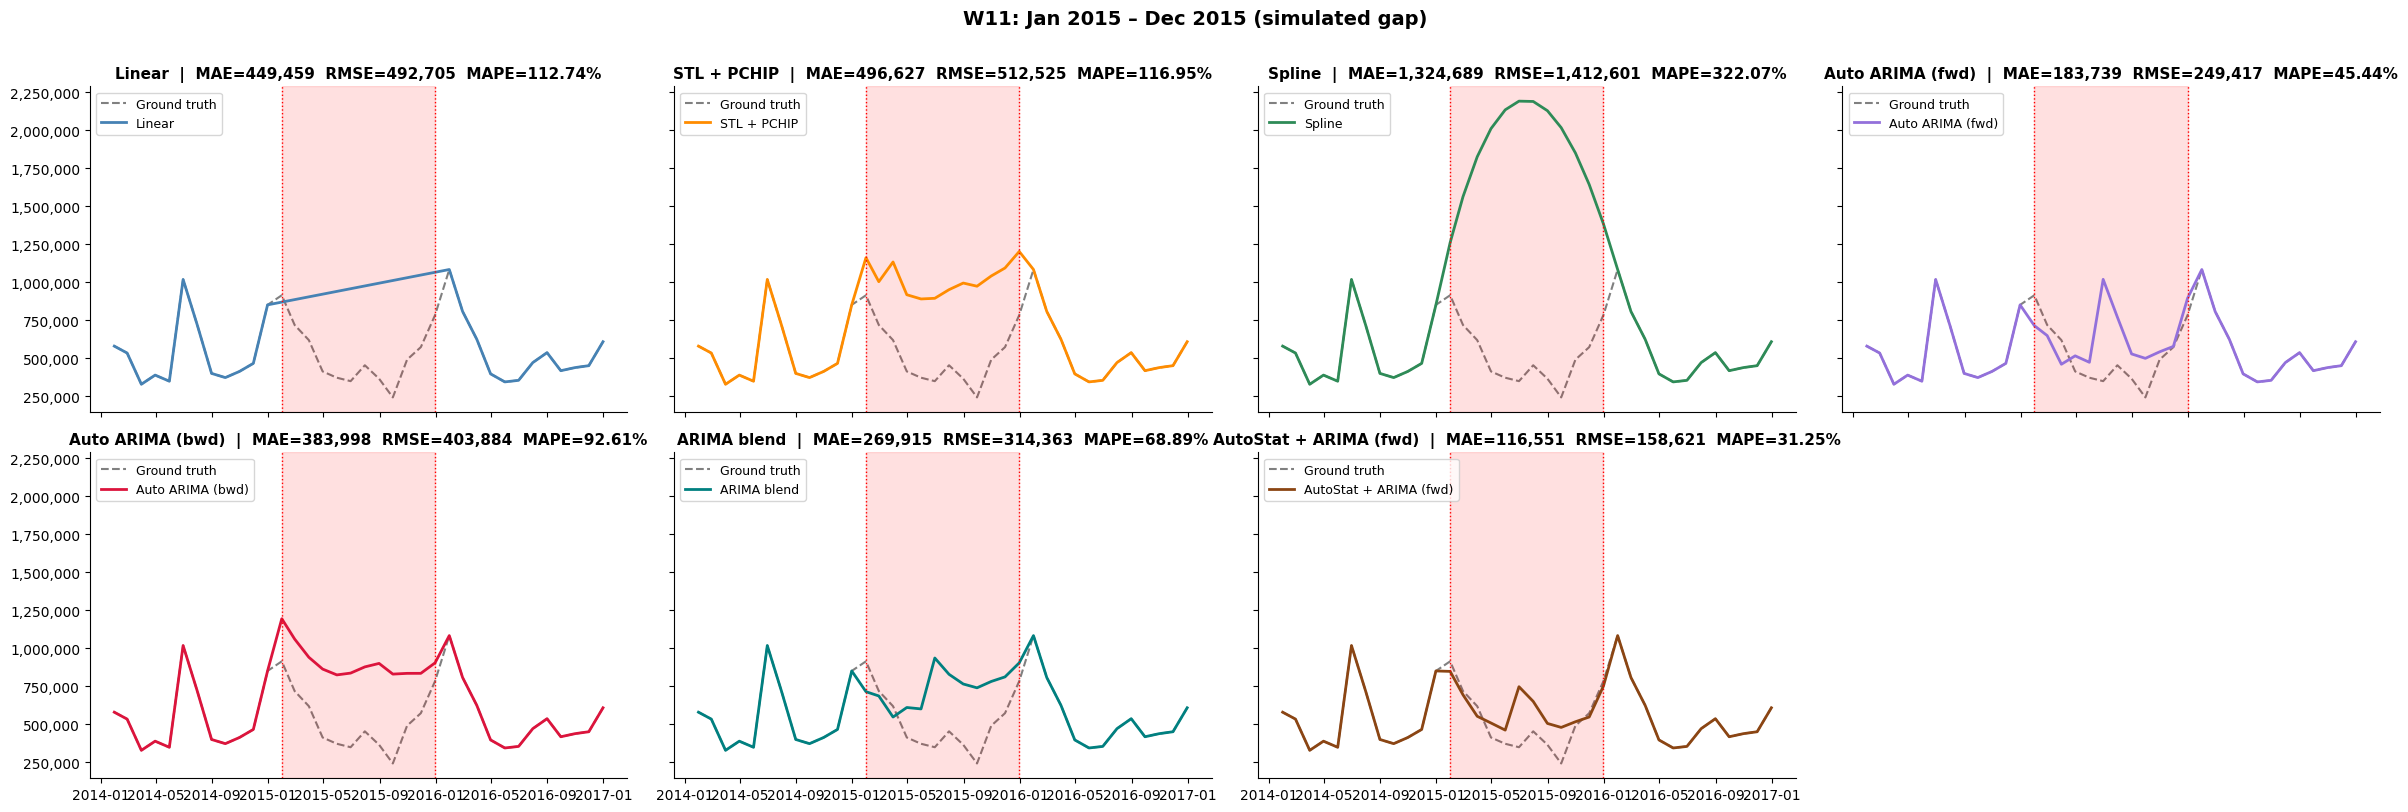

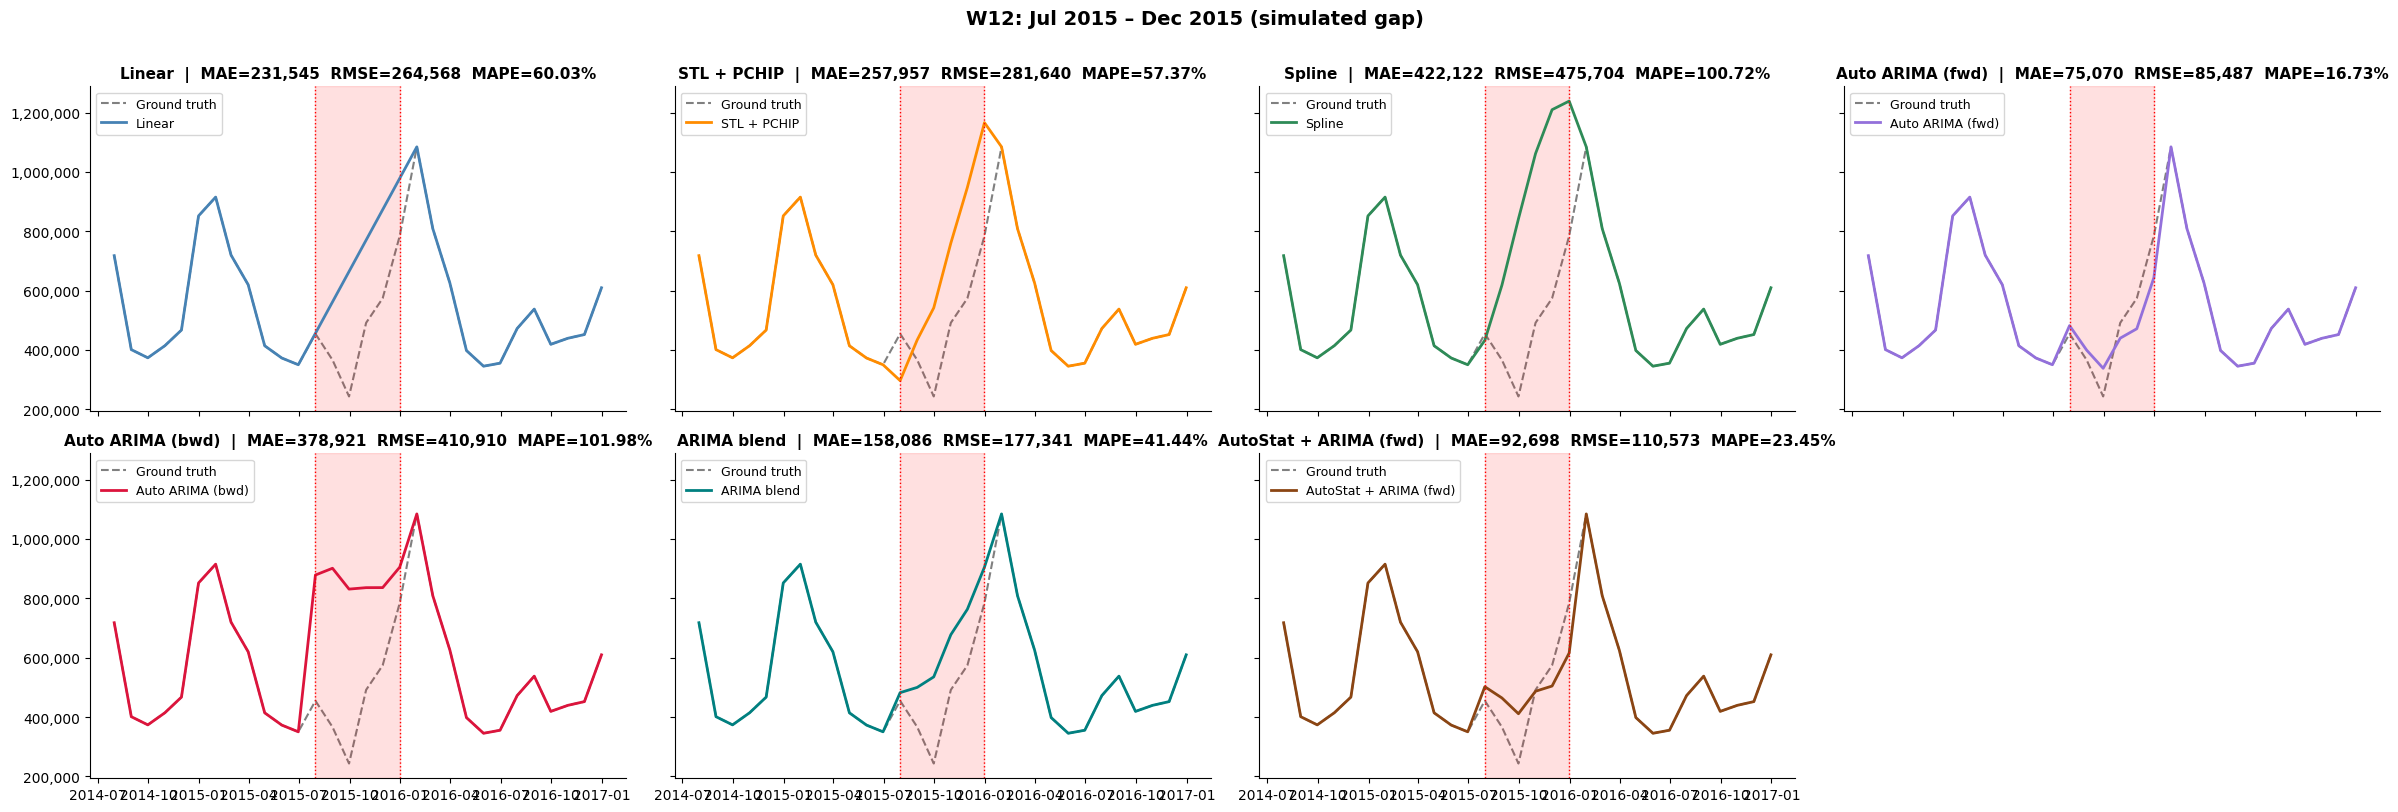

In [8]:
PLOT_BUFFER = pd.DateOffset(months=12)  # context shown around the gap
N_PER_WINDOW_PLOTS = 3  # only render the most recent windows

METHODS_TO_PLOT = [
    'Linear',
    'STL + PCHIP',
    'Spline',
    'Auto ARIMA (fwd)',
    'Auto ARIMA (bwd)',
    'ARIMA blend',
    'AutoStat + ARIMA (fwd)',
]

for win_name, gap_start, gap_end in WINDOWS[-N_PER_WINDOW_PLOTS:]:
    res = window_results[win_name]
    gap_mask = res['gap_mask']
    plot_start = gap_start - PLOT_BUFFER
    plot_end = gap_end + PLOT_BUFFER

    fig, axes = plt.subplots(2, 4, figsize=(24, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, method_name in zip(axes, METHODS_TO_PLOT):
        s_imputed = res[method_name]

        # original (ground truth) in grey dashes
        ax.plot(
            monthly_df[plot_start:plot_end].index,
            monthly_df.loc[plot_start:plot_end, 'arrival_count'],
            color='gray',
            linewidth=1.5,
            linestyle='--',
            label='Ground truth',
            zorder=1,
        )
        # imputed series
        color, ls = METHOD_STYLES[method_name]
        ax.plot(
            s_imputed[plot_start:plot_end].index,
            s_imputed[plot_start:plot_end],
            color=color,
            linewidth=2,
            linestyle=ls,
            label=method_name,
            zorder=2,
        )
        # gap region highlight
        ax.axvspan(gap_start, gap_end, alpha=0.12, color='red')
        ax.axvline(gap_start, color='red', linestyle=':', linewidth=1)
        ax.axvline(gap_end, color='red', linestyle=':', linewidth=1)

        # metrics annotation
        win_metrics = results_df[
            (results_df['Window'] == win_name) & (results_df['Method'] == method_name)
        ].iloc[0]
        ax.set_title(
            f'{method_name}  |  MAE={win_metrics["MAE"]:,.0f}  '
            f'RMSE={win_metrics["RMSE"]:,.0f}  MAPE={win_metrics["MAPE"]:.2f}%',
            fontsize=11,
            fontweight='bold',
        )
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
        ax.legend(loc='upper left', fontsize=9, frameon=True)
        sns.despine(ax=ax)

    for ax in axes[len(METHODS_TO_PLOT) :]:
        ax.set_visible(False)

    fig.suptitle(
        f'{win_name}: {gap_start.strftime("%b %Y")} – {gap_end.strftime("%b %Y")} (simulated gap)',
        fontsize=14,
        fontweight='bold',
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

## Aggregated Results

In [9]:
summary = (
    results_df
    .groupby('Method')[
        ['MAE', 'RMSE', 'MAPE', 'VarRatio', 'DownstreamRMSE', 'DownstreamMAPE']
    ]
    .mean()
    .round({
        'MAE': 0,
        'RMSE': 0,
        'MAPE': 2,
        'VarRatio': 3,
        'DownstreamRMSE': 0,
        'DownstreamMAPE': 2,
    })
    .sort_values('DownstreamMAPE')
)
summary.index.name = 'Method'
summary.columns = [
    'Mean MAE',
    'Mean RMSE',
    'Mean MAPE (%)',
    'Mean var_ratio',
    'Mean DS-RMSE',
    'Mean DS-MAPE (%)',
]

# rank by mean Downstream MAPE
summary.insert(0, 'Rank', range(1, len(summary) + 1))

oracle_summary = (
    results_df
    .groupby('Window')[['OracleRMSE', 'OracleMAPE']]
    .first()
    .round({'OracleRMSE': 0, 'OracleMAPE': 2})
)

print(
    f'\nAggregated benchmark (mean across {results_df["Window"].nunique()} windows, sorted by MAPE)'
)
print(
    'var_ratio = var(pred) / var(truth);  1.0 = ideal,  <1 over-smooth,  >1 over-spiky\n'
)
print(summary.to_string())

print(
    '\nOracle baseline per window (auto-ARIMA fit on the real series, same train/test geometry):\n'
)
print(oracle_summary.to_string())
summary


Aggregated benchmark (mean across 13 windows, sorted by MAPE)
var_ratio = var(pred) / var(truth);  1.0 = ideal,  <1 over-smooth,  >1 over-spiky

                        Rank  Mean MAE  Mean RMSE  Mean MAPE (%)  Mean var_ratio  Mean DS-RMSE  Mean DS-MAPE (%)
Method                                                                                                          
Auto ARIMA (fwd)           1  109768.0   140546.0          26.75           0.526       99237.0             19.60
AutoStat + ARIMA (fwd)     2   94292.0   122007.0          23.52           0.505      103924.0             20.55
STL + PCHIP                3  265105.0   286821.0          64.03           1.316      103114.0             20.84
ARIMA blend                4  159032.0   184203.0          40.30           0.484      109062.0             21.63
Linear                     5  252464.0   285461.0          64.72           0.471      114993.0             22.75
Auto ARIMA (bwd)           6  312016.0   344525.0          77.0

,Rank,Mean MAE,Mean RMSE,Mean MAPE (%),Mean var_ratio,Mean DS-RMSE,Mean DS-MAPE (%)
Method,,,,,,,
Auto ARIMA (fwd),1,109768.0,140546.0,26.75,0.526,99237.0,19.60
AutoStat + ARIMA (fwd),2,94292.0,122007.0,23.52,0.505,103924.0,20.55
STL + PCHIP,3,265105.0,286821.0,64.03,1.316,103114.0,20.84
ARIMA blend,4,159032.0,184203.0,40.30,0.484,109062.0,21.63
Linear,5,252464.0,285461.0,64.72,0.471,114993.0,22.75
Auto ARIMA (bwd),6,312016.0,344525.0,77.05,0.610,127721.0,25.62
Spline,7,930968.0,1012508.0,222.13,7.850,215686.0,43.99


## Method Comparison Plot

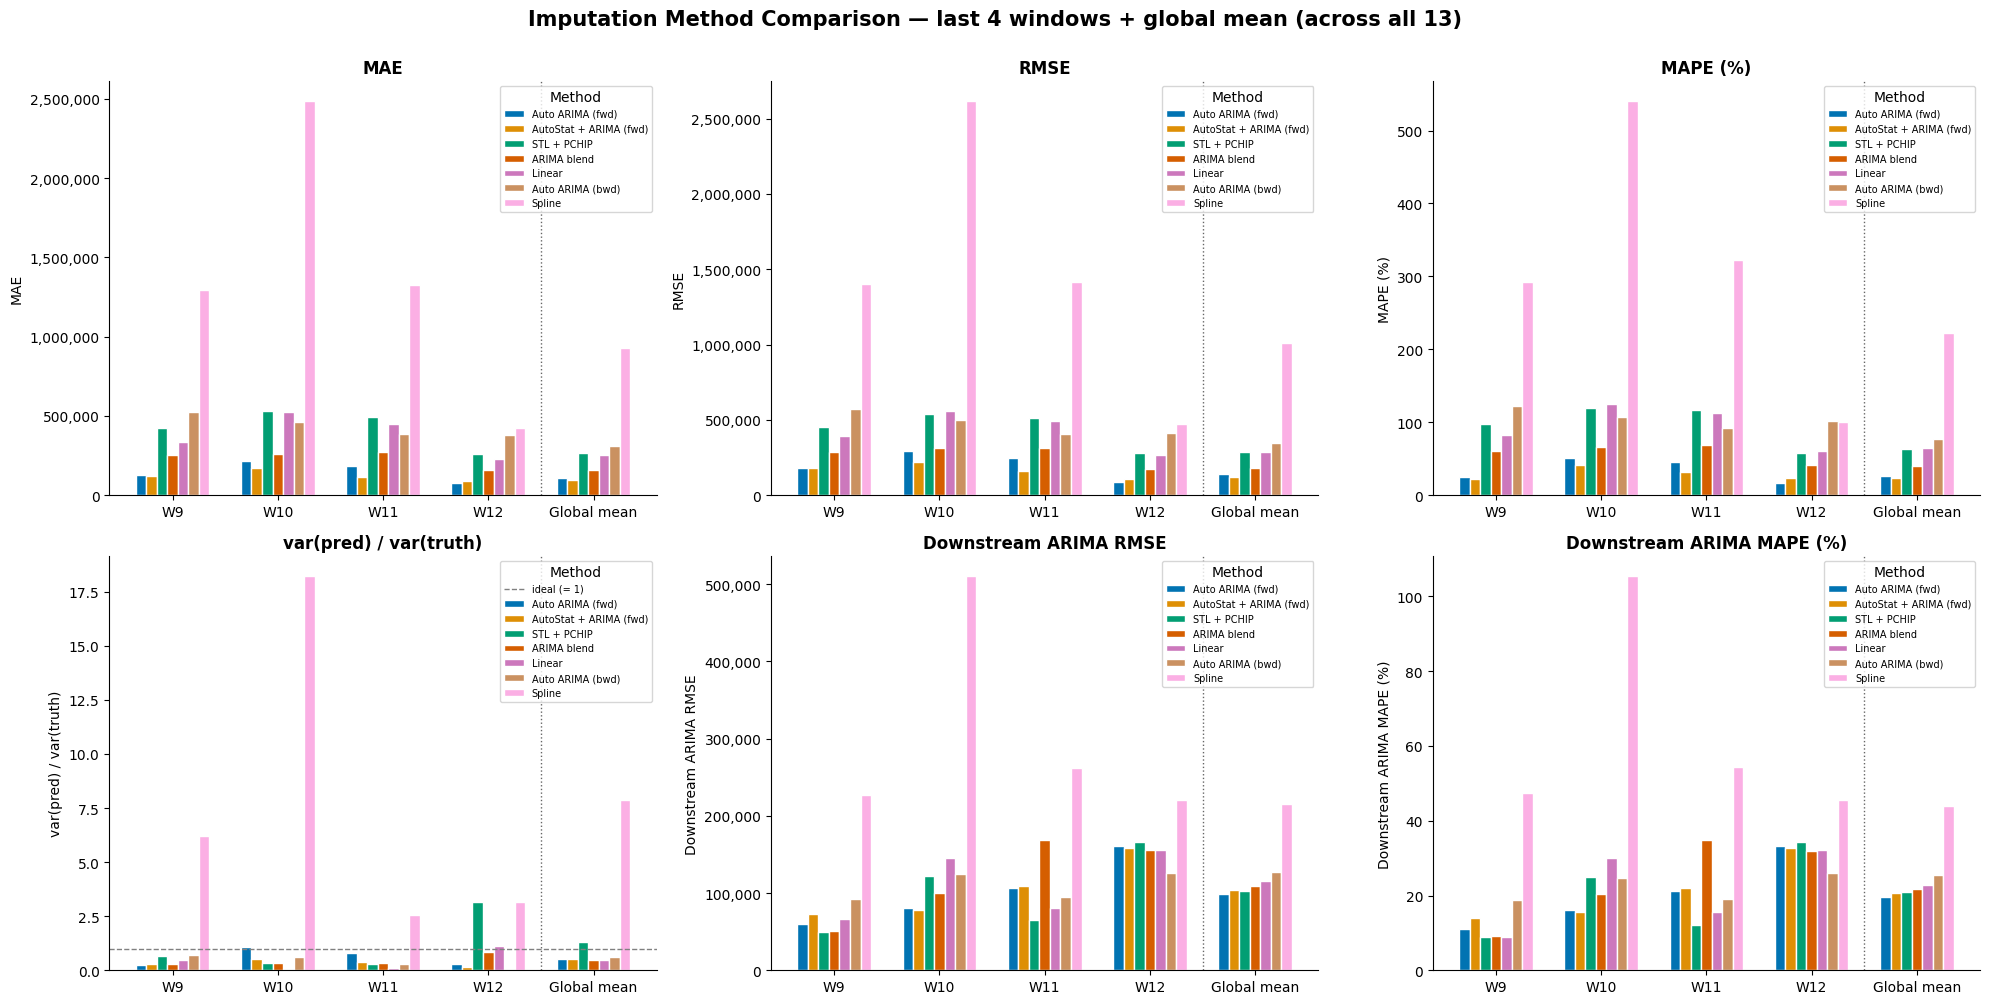

In [10]:
N_CHART_WINDOWS = 4  # most recent windows shown alongside the global mean

CHART_METRICS = [
    ('MAE', 'MAE', False, False),
    ('RMSE', 'RMSE', False, False),
    ('MAPE', 'MAPE (%)', True, False),
    ('VarRatio', 'var(pred) / var(truth)', False, True),  # ratio panel
    ('DownstreamRMSE', 'Downstream ARIMA RMSE', False, False),
    ('DownstreamMAPE', 'Downstream ARIMA MAPE (%)', True, False),
]
method_order = summary.index.tolist()  # already ranked by mean MAPE
window_order = [w[0] for w in WINDOWS]  # chronological

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax, (col, title, is_pct, is_ratio) in zip(axes, CHART_METRICS):
    pivot = results_df.pivot(index='Window', columns='Method', values=col).reindex(
        window_order
    )[method_order]

    recent = pivot.iloc[-N_CHART_WINDOWS:]
    global_mean = pivot.mean(axis=0, skipna=True).to_frame().T
    global_mean.index = ['Global mean']
    to_plot = pd.concat([recent, global_mean])

    to_plot.plot(kind='bar', ax=ax, width=0.7, edgecolor='white')

    # visually separate the "Global mean" bar from the per-window bars
    ax.axvline(len(recent) - 0.5, color='black', linestyle=':', linewidth=1, alpha=0.6)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Method', fontsize=7, loc='upper right')
    if not is_pct and not is_ratio:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    if is_ratio:
        ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='ideal (= 1)')
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title='Method', fontsize=7, loc='upper right')
    sns.despine(ax=ax)

fig.suptitle(
    f'Imputation Method Comparison — last {N_CHART_WINDOWS} windows + global mean (across all {len(WINDOWS)})',
    fontsize=15,
    fontweight='bold',
    y=1.00,
)
plt.tight_layout()
plt.show()

## Simple Testing with Pandemic Data

Apply each imputation method (including the AutoML AutoStat + ARIMA) to the **real** COVID
gap (2020-01 → 2021-12), then use the resulting fully-imputed series to forecast a
**validation year** and compare against its actual values.

The validation year is the **validation set of notebook 2** (`val.parquet`, the 12 months
before the test year); the test set is never used here. It is read from the data, so it rolls
forward when new data is added.

For each method:
1. Mask 2020-01 → 2021-12 and impute it (forward / backward / blend).
2. Fit an auto-ARIMA on the imputed series from 2010-01 up to the month before the
   validation year.
3. Forecast 12 months → score against the real values of the validation year.

An **oracle baseline** (auto-ARIMA fitted on the same train window but with the *real* COVID
values) is included as the upper bound on achievable accuracy.

In [11]:
FORECAST_TRAIN_START = pd.Timestamp('2010-01-01')
# validation year = val.parquet (notebook 2), the last months of monthly_df
val_dates = pd.DatetimeIndex(
    pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'val.parquet'))['date'].unique()
).sort_values()
N_FORECAST = len(val_dates)
FORECAST_TEST_START = val_dates[0]
FORECAST_TEST_END = val_dates[-1]
FORECAST_TRAIN_END = FORECAST_TEST_START - pd.offsets.MonthEnd(1)
assert monthly_df.index[-N_FORECAST:].equals(val_dates), 'validation must end the data'
VALIDATION_LABEL = f'{FORECAST_TEST_START:%b %Y}–{FORECAST_TEST_END:%b %Y}'
print(
    f'Forecast training: {FORECAST_TRAIN_START:%b %Y} → {FORECAST_TRAIN_END:%b %Y} | '
    f'validation: {VALIDATION_LABEL}'
)

series = monthly_df['arrival_count'].copy()
covid_mask = (series.index >= COVID_START) & (series.index <= COVID_END)

masked_covid = series.copy()
masked_covid[covid_mask] = np.nan

pre_covid_end = series[series.index < COVID_START].index[-1]
post_covid_start = series[series.index > COVID_END].index[0]

# Impute the real COVID gap with all methods
s_linear_covid = apply_linear(masked_covid)
s_stl_pchip_covid = apply_stl_pchip(masked_covid, covid_mask, pre_covid_end)
s_spline_covid = apply_spline(masked_covid)

s_fwd, fwd_model, forecast_fwd_covid = apply_auto_arima(
    masked_covid, covid_mask, pre_covid_end
)
print(f'Forward ARIMA order:  {fwd_model.order} x {fwd_model.seasonal_order}')

s_bwd, bwd_model, forecast_bwd_covid = apply_auto_arima_bwd(
    masked_covid, covid_mask, post_covid_start, FORECAST_TRAIN_END
)
print(f'Backward ARIMA order: {bwd_model.order} x {bwd_model.seasonal_order}')

s_blend = apply_arima_blend(
    masked_covid, covid_mask, forecast_fwd_covid, forecast_bwd_covid
)

s_ast_covid, ast_covid, ast_covid_arima = apply_auto_stationary_arima(
    masked_covid, covid_mask, pre_covid_end
)
print(
    f'AutoStat pipeline:    {describe_pipeline(ast_covid)}  |  '
    f'ARIMA {ast_covid_arima.order} x {ast_covid_arima.seasonal_order}'
)

imputed_variants = {
    'Linear': s_linear_covid,
    'STL + PCHIP': s_stl_pchip_covid,
    'Spline': s_spline_covid,
    'Auto ARIMA (fwd)': s_fwd,
    'Auto ARIMA (bwd)': s_bwd,
    'ARIMA blend': s_blend,
    'AutoStat + ARIMA (fwd)': s_ast_covid,
}

# Real ground truth of the validation year
y_test = series.loc[FORECAST_TEST_START:FORECAST_TEST_END]
assert len(y_test) == N_FORECAST, (
    f'Expected {N_FORECAST} test months, got {len(y_test)}'
)

# Oracle: real COVID values + auto-ARIMA trained up to FORECAST_TRAIN_END
oracle_train = series.loc[FORECAST_TRAIN_START:FORECAST_TRAIN_END]
oracle_forecast = _fit_predict_auto_arima(oracle_train.values, N_FORECAST)
oracle_rmse_val = rmse(y_test.values, oracle_forecast)
oracle_mape_val = mape(y_test.values, oracle_forecast)
print(
    f'\nOracle (real COVID values)  RMSE={oracle_rmse_val:>10,.0f}  '
    f'MAPE={oracle_mape_val:>6.2f}%'
)

forecast_records = []
forecasts_val = {'Oracle': pd.Series(oracle_forecast, index=y_test.index)}

print(f'\n  {"Method":<20}  {"RMSE":>10}  {"MAPE":>8}')
for method_name, s_imputed in imputed_variants.items():
    train = s_imputed.loc[FORECAST_TRAIN_START:FORECAST_TRAIN_END]
    forecast = _fit_predict_auto_arima(train.values, N_FORECAST)
    forecast = np.clip(forecast, 0, None)

    r = rmse(y_test.values, forecast)
    m = mape(y_test.values, forecast)
    forecast_records.append({'Method': method_name, 'RMSE': r, 'MAPE': m})
    forecasts_val[method_name] = pd.Series(forecast, index=y_test.index)
    print(f'  {method_name:<20}  {r:>10,.0f}  {m:>7.2f}%')

forecast_results_df = (
    pd.DataFrame(forecast_records).set_index('Method').round({'RMSE': 0, 'MAPE': 2})
)
forecast_results_df

Forecast training: Jan 2010 → Aug 2024 | validation: Sep 2024–Aug 2025
Forward ARIMA order:  (2, 1, 2) x (1, 0, 0, 12)
Backward ARIMA order: (0, 1, 0) x (0, 0, 1, 12)
AutoStat pipeline:    Detrending → Deseasonalizing  |  ARIMA (2, 1, 2) x (1, 0, 0, 12)

Oracle (real COVID values)  RMSE=   315,692  MAPE= 26.07%

  Method                      RMSE      MAPE
  Linear                   338,880    25.15%
  STL + PCHIP              327,293    30.61%
  Spline                   389,791    38.68%
  Auto ARIMA (fwd)         352,792    30.75%
  Auto ARIMA (bwd)         324,110    23.00%
  ARIMA blend              347,360    30.63%
  AutoStat + ARIMA (fwd)     346,371    30.74%


,RMSE,MAPE
Method,,
Linear,338880.0,25.15
STL + PCHIP,327293.0,30.61
Spline,389791.0,38.68
Auto ARIMA (fwd),352792.0,30.75
Auto ARIMA (bwd),324110.0,23.00
ARIMA blend,347360.0,30.63
AutoStat + ARIMA (fwd),346371.0,30.74


Post-COVID train span: 2022-01-31 → 2024-08-31 (32 months)

Post-COVID only (no imputation)   RMSE=   301,951  MAPE= 22.42%


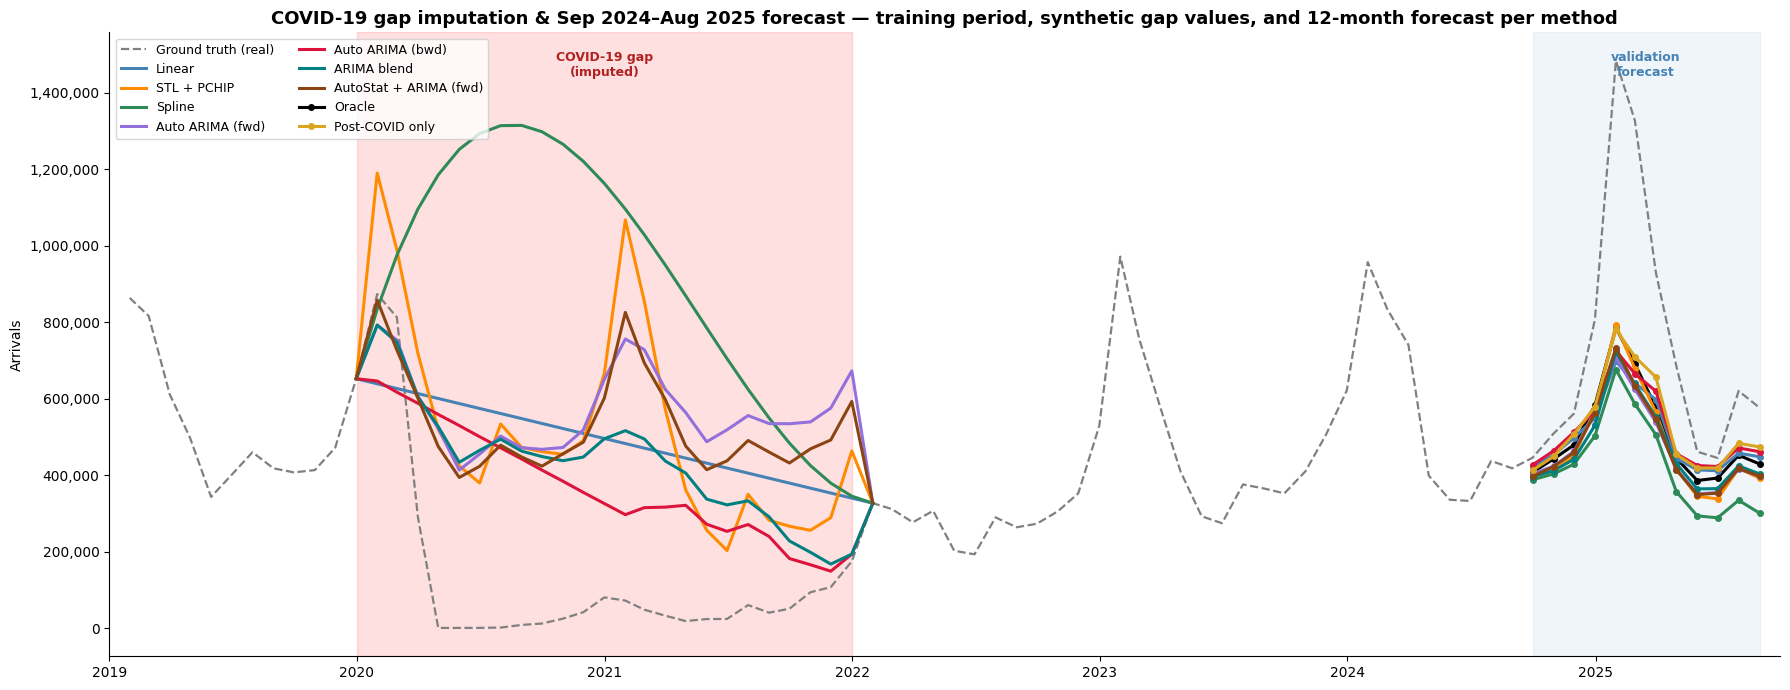

,RMSE,MAPE
Method,,
Post-COVID only,301951.0,22.42
Auto ARIMA (bwd),324110.0,23.00
Linear,338880.0,25.15
STL + PCHIP,327293.0,30.61
ARIMA blend,347360.0,30.63
AutoStat + ARIMA (fwd),346371.0,30.74
Auto ARIMA (fwd),352792.0,30.75
Spline,389791.0,38.68


In [12]:
POST_COVID_TRAIN_START = pd.Timestamp('2022-01-01')

post_covid_train = series.loc[POST_COVID_TRAIN_START:FORECAST_TRAIN_END]
print(
    f'Post-COVID train span: {post_covid_train.index.min().date()} → '
    f'{post_covid_train.index.max().date()} ({len(post_covid_train)} months)'
)

post_covid_forecast = _fit_predict_auto_arima(post_covid_train.values, N_FORECAST)
post_covid_forecast = np.clip(post_covid_forecast, 0, None)

post_covid_rmse = rmse(y_test.values, post_covid_forecast)
post_covid_mape = mape(y_test.values, post_covid_forecast)
print(
    f'\nPost-COVID only (no imputation)   RMSE={post_covid_rmse:>10,.0f}  '
    f'MAPE={post_covid_mape:>6.2f}%'
)

forecasts_val['Post-COVID only'] = pd.Series(post_covid_forecast, index=y_test.index)
forecast_results_df.loc['Post-COVID only'] = [
    round(post_covid_rmse),
    round(post_covid_mape, 2),
]

# ---- Single chart: training (from 2019) + COVID-19 gap imputations + validation ----
PLOT_START = pd.Timestamp('2019-01-01')

forecast_styles_ext = {
    'Oracle': ('black', '-'),
    'Linear': METHOD_STYLES['Linear'],
    'STL + PCHIP': METHOD_STYLES['STL + PCHIP'],
    'Spline': METHOD_STYLES['Spline'],
    'Auto ARIMA (fwd)': METHOD_STYLES['Auto ARIMA (fwd)'],
    'Auto ARIMA (bwd)': METHOD_STYLES['Auto ARIMA (bwd)'],
    'ARIMA blend': METHOD_STYLES['ARIMA blend'],
    'AutoStat + ARIMA (fwd)': METHOD_STYLES['AutoStat + ARIMA (fwd)'],
    'Post-COVID only': ('goldenrod', '-'),
}

fig, ax = plt.subplots(figsize=(18, 7))

ax.axvspan(COVID_START, COVID_END, alpha=0.12, color='red', zorder=0)
ax.axvspan(
    FORECAST_TEST_START, FORECAST_TEST_END, alpha=0.08, color='steelblue', zorder=0
)

trans = ax.get_xaxis_transform()
ax.text(
    COVID_START + (COVID_END - COVID_START) / 2,
    0.97,
    'COVID-19 gap\n(imputed)',
    transform=trans,
    ha='center',
    va='top',
    fontsize=9,
    color='firebrick',
    fontweight='bold',
)
ax.text(
    FORECAST_TEST_START + (FORECAST_TEST_END - FORECAST_TEST_START) / 2,
    0.97,
    'validation\nforecast',
    transform=trans,
    ha='center',
    va='top',
    fontsize=9,
    color='steelblue',
    fontweight='bold',
)

# Ground truth
real = series.loc[PLOT_START:FORECAST_TEST_END]
ax.plot(
    real.index,
    real.values,
    color='gray',
    linewidth=1.6,
    linestyle='--',
    label='Ground truth (real)',
    zorder=2,
)

# Imputation curves over the COVID gap (one anchor point on each side for visual continuity)
for method_name, s_imputed in imputed_variants.items():
    color, ls = METHOD_STYLES[method_name]
    seg = s_imputed.loc[pre_covid_end:post_covid_start]
    ax.plot(
        seg.index,
        seg.values,
        color=color,
        linewidth=2.2,
        linestyle=ls,
        label=method_name,
        zorder=3,
    )

# validation forecast per method
for name, fc in forecasts_val.items():
    color, ls = forecast_styles_ext[name]
    label = None if name in imputed_variants else name
    ax.plot(
        fc.index,
        fc.values,
        color=color,
        linewidth=2.2,
        linestyle=ls,
        marker='o',
        markersize=4,
        label=label,
        zorder=3,
    )

ax.set_title(
    f'COVID-19 gap imputation & {VALIDATION_LABEL} forecast — training period, '
    'synthetic gap values, and 12-month forecast per method',
    fontsize=13,
    fontweight='bold',
)
ax.set_xlabel('')
ax.set_ylabel('Arrivals')
ax.set_xlim(PLOT_START, FORECAST_TEST_END + pd.DateOffset(months=1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='upper left', fontsize=9, frameon=True, ncol=2)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

forecast_results_df.sort_values('MAPE')

### Persist the Imputed Series

The COVID-imputed training series are saved to `data/processed/train_covid_imputed.parquet`
so the modelling notebooks (e.g. notebook 5, ARIMA baseline) can train on a series without
the structural break. One column per imputation method; `arrival_count` keeps the real
values. Only the **training period** is saved (up to the month before the validation year), so
neither the validation year nor the test set leaks into a model trained on this file.

In [13]:
imputed_train_df = pd.DataFrame({'arrival_count': series, **imputed_variants}).loc[
    :FORECAST_TRAIN_END
]
imputed_train_df.index.name = 'date'
imputed_train_df.to_parquet(
    os.path.join(DATA_FOLDER_PATH, 'train_covid_imputed.parquet')
)

imputed_train_df.loc[COVID_START:COVID_END].round(0)

,arrival_count,Linear,STL + PCHIP,Spline,Auto ARIMA (fwd),Auto ARIMA (bwd),ARIMA blend,AutoStat + ARIMA (fwd)
date,,,,,,,,
2020-01-31,873295.0,638860.0,1190021.0,834171.0,792362.0,646130.0,792362.0,857701.0
2020-02-29,812726.0,626475.0,988970.0,974854.0,753218.0,617007.0,747296.0,726913.0
2020-03-31,290234.0,613235.0,718523.0,1095584.0,606155.0,587884.0,604566.0,601255.0
2020-04-30,559.0,600423.0,519677.0,1185215.0,522252.0,558761.0,527014.0,475024.0
2020-05-31,517.0,587184.0,424131.0,1251810.0,413328.0,529638.0,433556.0,393939.0
2020-06-30,655.0,574372.0,379528.0,1293068.0,455025.0,500515.0,464914.0,423030.0
2020-07-31,1459.0,561133.0,533852.0,1313826.0,502036.0,471393.0,494042.0,478437.0
2020-08-31,8305.0,547893.0,472461.0,1314469.0,471717.0,442270.0,462755.0,447475.0
2020-09-30,12010.0,535081.0,461438.0,1297959.0,467497.0,413147.0,448593.0,423524.0


## AutoML Target Transformation for the Validation Forecast

The section above changes *how the COVID gap is filled* and always forecasts with a
plain auto-ARIMA (`d=1`, `D=0`) on the raw scale. This section also changes *how the
forecaster sees the target*. Every training series is passed through
`AutoStationaryTransformer` (Joseph & Tackes, *Modern Time Series Forecasting with
Python* 2E) before the auto-ARIMA, and the validation forecast is inverse-transformed back to
arrivals.

Two questions:

1. **What does the AutoML pipeline pick for each training series?** Notebook 3 showed
   that the COVID break masks the trend test and distorts the Guerrero λ. Comparing the
   pipeline fitted on the *real* series (with the pandemic) against the pipelines fitted
   on the *imputed* series shows how much each imputation "repairs" the statistical
   structure the transformer relies on.
2. **Does forecasting in the stationary space beat the raw-scale ARIMA** for the same
   training series?

Training spans are the same as above: from `2010-01` for the oracle and every imputed
series, and from `2022-01` for *Post-COVID only*, both up to the month before the
validation year.

In [14]:
from statsmodels.tsa.stattools import adfuller, kpss  # noqa: E402

training_series = {
    'Oracle': series.loc[FORECAST_TRAIN_START:FORECAST_TRAIN_END],
    **{
        name: s_imputed.loc[FORECAST_TRAIN_START:FORECAST_TRAIN_END]
        for name, s_imputed in imputed_variants.items()
    },
    'Post-COVID only': post_covid_train,
}

diagnostic_rows = []
for name, train in training_series.items():
    ast = fit_auto_stationary(train)
    stationary = ast.transform(train)
    box_cox = [tr for tr in ast._pipeline if isinstance(tr, BoxCoxTransformer)]
    adf_p = adfuller(stationary.to_numpy(), autolag='AIC')[1]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_p = kpss(stationary.to_numpy(), regression='c', nlags='auto')[1]
    diagnostic_rows.append({
        'Training series': name,
        'n': len(train),
        'Pipeline': describe_pipeline(ast),
        'Trend (MK p)': f'{"✓" if ast._trend_check["trend"] else "✗"} '
        f'({ast._trend_check["p_value"]:.4f})',
        'Seasonal (m=12)': '✓' if ast._seasonality_check['seasonal'] else '✗',
        'Heteroscedastic (White p)': (
            f'{"✓" if ast._hetero_check["heteroscedastic"] else "✗"} '
            f'({ast._hetero_check["lm_p_value"]:.4f})'
        ),
        'Box-Cox λ': f'{box_cox[0].boxcox_lambda:.3f}' if box_cox else '—',
        'ADF p (output)': round(adf_p, 4),
        'KPSS p (output)': round(kpss_p, 4),
    })

ast_diagnostics = pd.DataFrame(diagnostic_rows).set_index('Training series')
print('AutoStationaryTransformer fitted on each validation-forecast training series')
print(ast_diagnostics.T.to_string())

AutoStationaryTransformer fitted on each validation-forecast training series
Training series                                                  Oracle           Linear      STL + PCHIP                    Spline Auto ARIMA (fwd)              Auto ARIMA (bwd)      ARIMA blend AutoStat + ARIMA (fwd)  Post-COVID only
n                                                                   176              176              176                       176              176                           176              176                    176               32
Pipeline                   Detrending → Deseasonalizing → AddM → BoxCox  Deseasonalizing  Deseasonalizing  Deseasonalizing → BoxCox  Deseasonalizing  Detrending → Deseasonalizing  Deseasonalizing        Deseasonalizing  Deseasonalizing
Trend (MK p)                                                 ✓ (0.0113)       ✗ (0.4239)       ✗ (0.3892)                ✗ (0.2151)       ✗ (0.5622)                    ✓ (0.0284)       ✗ (0.1574)             ✗ (1.00

In [15]:
ast_forecasts_val = {}
comparison_rows = []
raw_scores = {
    'Oracle': (oracle_rmse_val, oracle_mape_val),
    **{
        name: (row['RMSE'], row['MAPE']) for name, row in forecast_results_df.iterrows()
    },
}

for name, train in training_series.items():
    forecast, ast, model = fit_predict_auto_stationary_arima(train, N_FORECAST)
    ast_forecasts_val[name] = pd.Series(forecast, index=y_test.index)
    raw_rmse, raw_mape = raw_scores[name]
    ast_rmse, ast_mape = rmse(y_test.values, forecast), mape(y_test.values, forecast)
    comparison_rows.append({
        'Training series': name,
        'ARIMA order (stationary)': f'{model.order} x {model.seasonal_order}',
        'RMSE raw ARIMA': round(raw_rmse),
        'RMSE AutoStat+ARIMA': round(ast_rmse),
        'MAPE raw ARIMA (%)': round(raw_mape, 2),
        'MAPE AutoStat+ARIMA (%)': round(ast_mape, 2),
        'Δ MAPE (pp)': round(ast_mape - raw_mape, 2),
    })

ast_comparison = (
    pd
    .DataFrame(comparison_rows)
    .set_index('Training series')
    .sort_values('MAPE AutoStat+ARIMA (%)')
)
print(
    f'{VALIDATION_LABEL} forecast — raw-scale auto-ARIMA vs '
    'AutoStationaryTransformer + auto-ARIMA'
)
print('Δ MAPE < 0 → the AutoML target transformation improved the forecast\n')
print(ast_comparison.to_string())

Sep 2024–Aug 2025 forecast — raw-scale auto-ARIMA vs AutoStationaryTransformer + auto-ARIMA
Δ MAPE < 0 → the AutoML target transformation improved the forecast

                         ARIMA order (stationary)  RMSE raw ARIMA  RMSE AutoStat+ARIMA  MAPE raw ARIMA (%)  MAPE AutoStat+ARIMA (%)  Δ MAPE (pp)
Training series                                                                                                                                 
Post-COVID only         (0, 1, 0) x (0, 0, 0, 12)          301951               226725               22.42                    17.18        -5.24
Linear                  (1, 0, 1) x (2, 0, 1, 12)          338880               262265               25.15                    19.69        -5.46
ARIMA blend             (1, 0, 0) x (2, 0, 2, 12)          347360               276545               30.63                    23.86        -6.77
Spline                  (1, 0, 0) x (0, 0, 0, 12)          389791               311198               38.68        

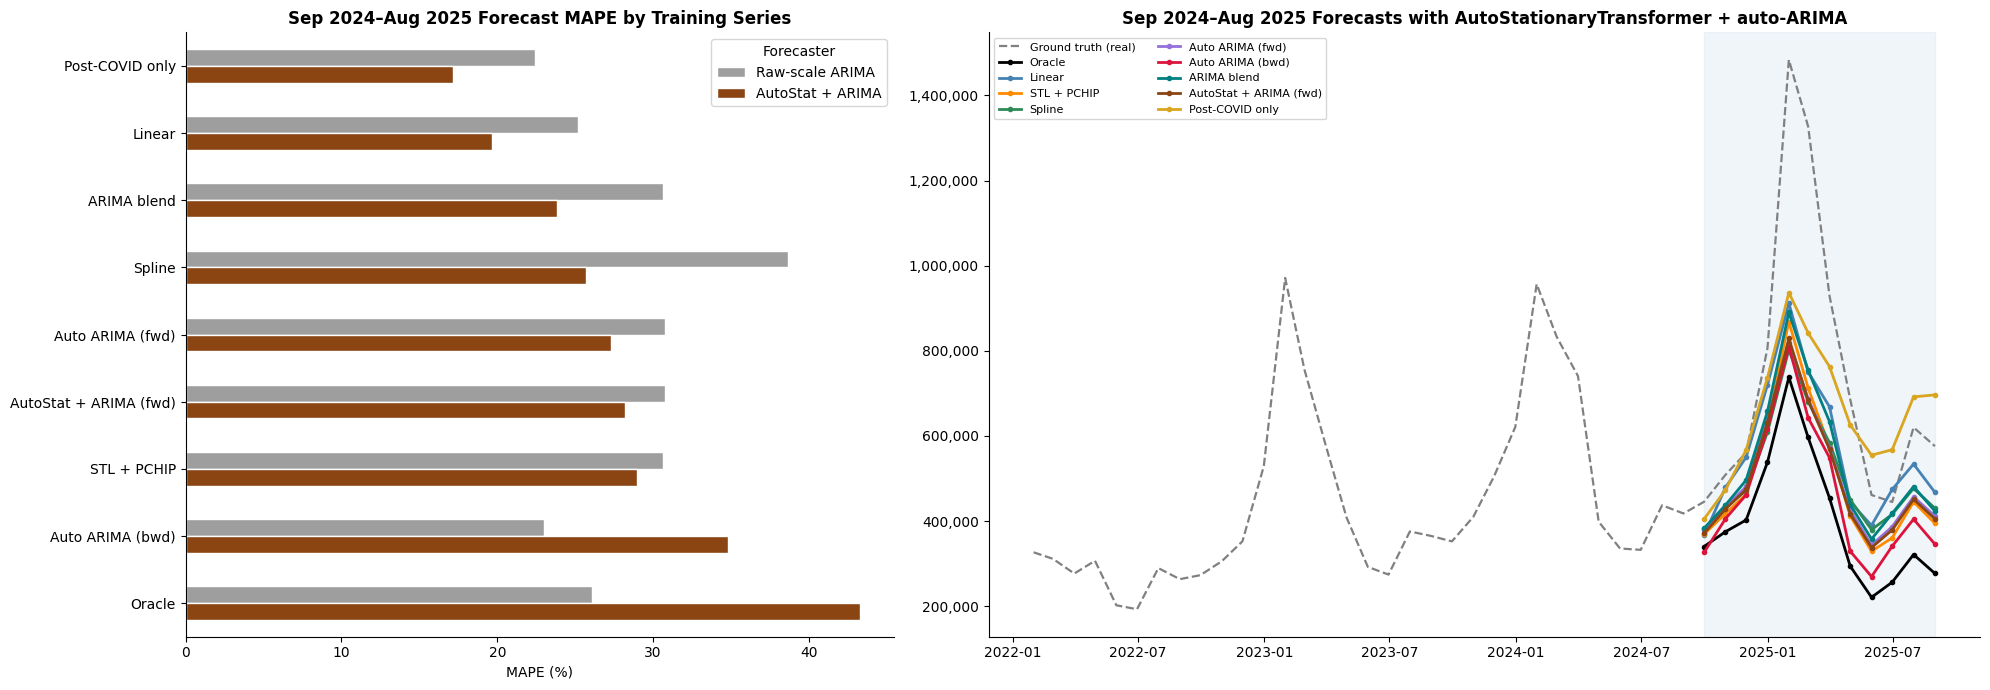

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={'width_ratios': [1, 1.4]})

# ── left: MAPE raw vs AutoStat per training series ──────────────────────────
mape_plot = ast_comparison[['MAPE raw ARIMA (%)', 'MAPE AutoStat+ARIMA (%)']]
mape_plot.columns = ['Raw-scale ARIMA', 'AutoStat + ARIMA']
mape_plot.plot(
    kind='barh', ax=axes[0], color=['#9e9e9e', 'saddlebrown'], edgecolor='white'
)
axes[0].invert_yaxis()
axes[0].set_title(
    f'{VALIDATION_LABEL} Forecast MAPE by Training Series', fontweight='bold'
)
axes[0].set_xlabel('MAPE (%)')
axes[0].set_ylabel('')
axes[0].legend(title='Forecaster', frameon=True)
sns.despine(ax=axes[0])

# ── right: validation AutoStat forecasts vs ground truth ──────────────────────────
context = series.loc[pd.Timestamp('2022-01-01') : FORECAST_TEST_END]
axes[1].plot(
    context.index,
    context.values,
    color='gray',
    linestyle='--',
    linewidth=1.6,
    label='Ground truth (real)',
)
for name, fc in ast_forecasts_val.items():
    color, ls = forecast_styles_ext[name]
    axes[1].plot(
        fc.index,
        fc.values,
        color=color,
        linestyle=ls,
        linewidth=2,
        marker='o',
        markersize=3,
        label=name,
    )
axes[1].axvspan(FORECAST_TEST_START, FORECAST_TEST_END, alpha=0.08, color='steelblue')
axes[1].set_title(
    f'{VALIDATION_LABEL} Forecasts with AutoStationaryTransformer + auto-ARIMA',
    fontweight='bold',
)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(fontsize=8, ncol=2, frameon=True, loc='upper left')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()